In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt

In [2]:
# Load data

# # naive to .8 * tight
# loaded_data = np.load(os.path.join("Data", "QUBO_RQUBO_Noisy_Results_Beyond_Tight.npz"))

# tight to naive (noisy, QAOA P=3)
loaded_data = np.load(os.path.join("Data", "QUBO_RQUBO_Noisy_Results_P3.npz")) #using this one in paper :)

# # tight to naive (noisy, QAOA P=3, random initialization)
# loaded_data = np.load(os.path.join("Data", "QUBO_RQUBO_Noisy_Results_P3_random_init.npz"))

# # 1e5 * naive to tight (noisy)
# loaded_data = np.load(os.path.join("Data", "QUBO_RQUBO_Noisy_Results.npz"))

# # 1e5 * naive to tight (noiseless)
# loaded_data = np.load(os.path.join("Data", "QUBO_RQUBO_Results.npz"))

QUBO_EXP_VALS = loaded_data['QUBO_EXP_VALS']
QUBO_FEASIBILITY = loaded_data['QUBO_FEASIBILITY']
RQUBO_EXP_VALS = loaded_data['RQUBO_EXP_VALS']
RQUBO_FEASIBILITY = loaded_data['RQUBO_FEASIBILITY']

number_of_pens = QUBO_EXP_VALS.shape[1]
penalty_list = np.linspace(0, 1, number_of_pens)
num_graphs = QUBO_EXP_VALS.shape[0]

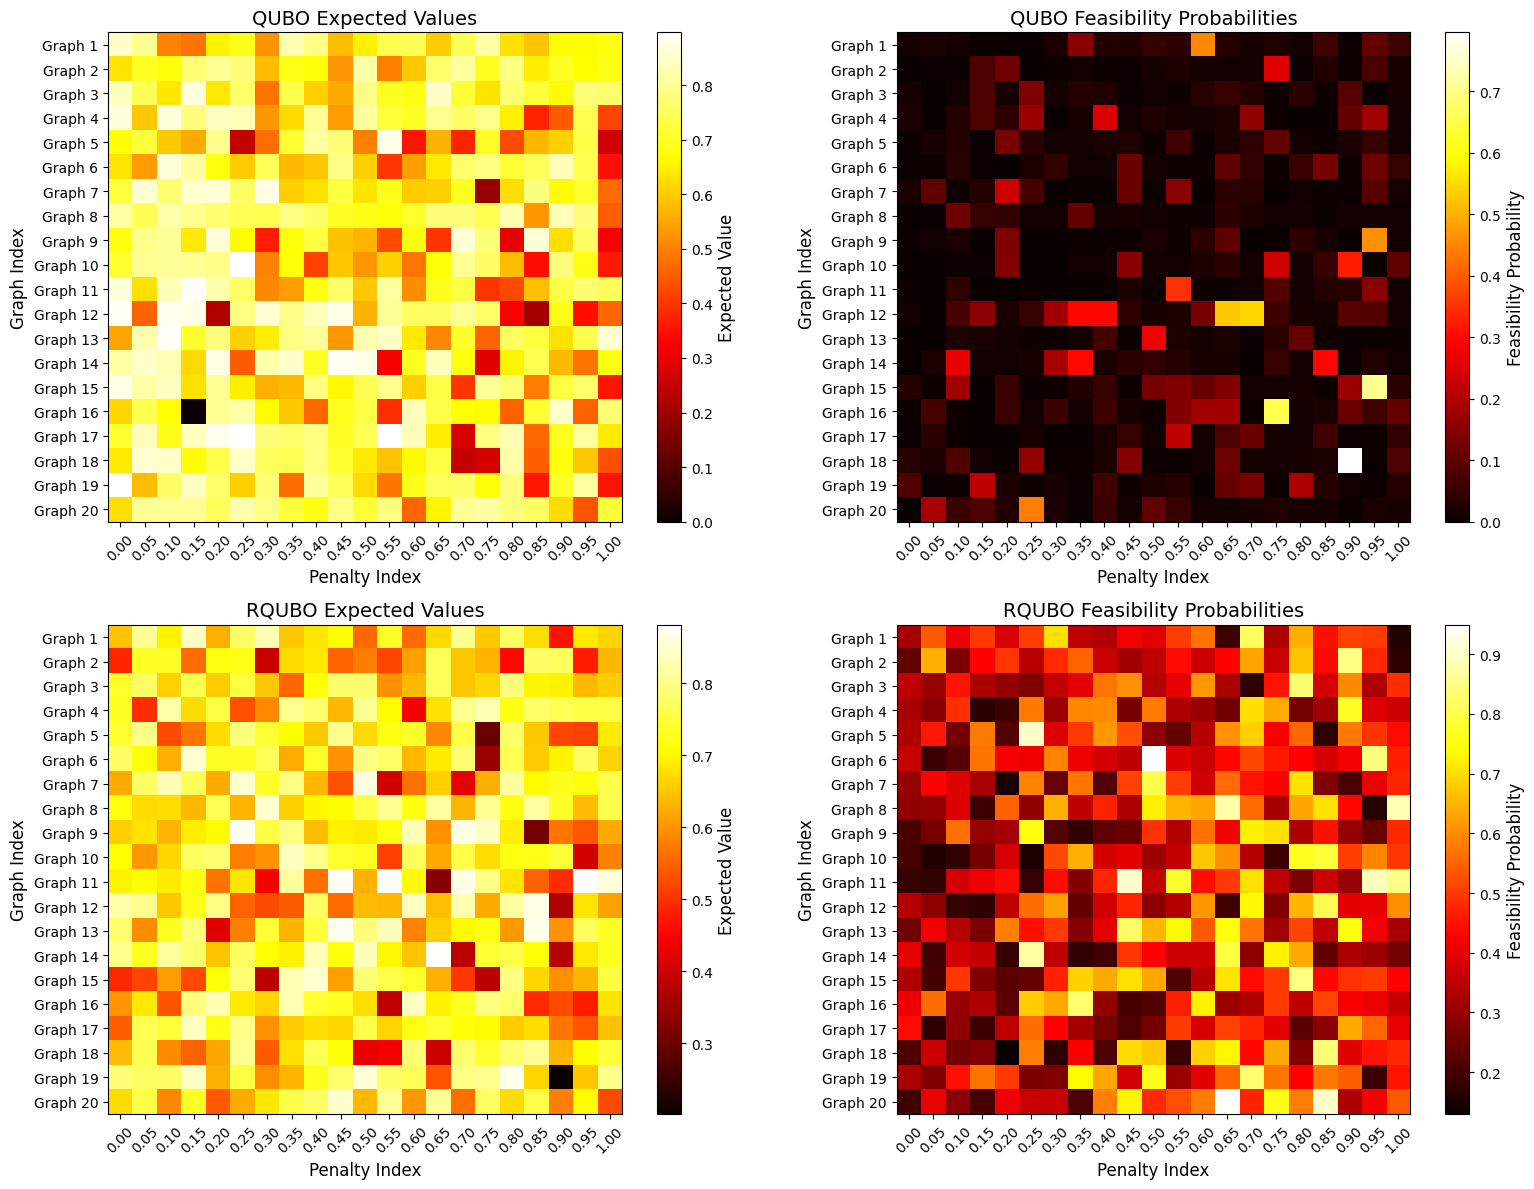

In [3]:
fig, axs = plt.subplots(2, 2, figsize=(16, 12))

# QUBO Expected Values
im0 = axs[0, 0].imshow(QUBO_EXP_VALS, cmap='hot', interpolation='nearest')
cbar0 = fig.colorbar(im0, ax=axs[0, 0])
cbar0.set_label('Expected Value', fontsize=12)
axs[0, 0].set_title('QUBO Expected Values', fontsize=14)
axs[0, 0].set_xlabel('Penalty Index', fontsize=12)
axs[0, 0].set_ylabel('Graph Index', fontsize=12)
axs[0, 0].set_xticks(np.arange(len(penalty_list)))
axs[0, 0].set_xticklabels([f'{p:.2f}' for p in penalty_list], rotation=45, fontsize=10)
axs[0, 0].set_yticks(np.arange(num_graphs))
axs[0, 0].set_yticklabels([f'Graph {i+1}' for i in range(num_graphs)], fontsize=10)

# QUBO Feasibility Probabilities
im1 = axs[0, 1].imshow(QUBO_FEASIBILITY, cmap='hot', interpolation='nearest')
cbar1 = fig.colorbar(im1, ax=axs[0, 1])
cbar1.set_label('Feasibility Probability', fontsize=12)
axs[0, 1].set_title('QUBO Feasibility Probabilities', fontsize=14)
axs[0, 1].set_xlabel('Penalty Index', fontsize=12)
axs[0, 1].set_ylabel('Graph Index', fontsize=12)
axs[0, 1].set_xticks(np.arange(len(penalty_list)))
axs[0, 1].set_xticklabels([f'{p:.2f}' for p in penalty_list], rotation=45, fontsize=10)
axs[0, 1].set_yticks(np.arange(num_graphs))
axs[0, 1].set_yticklabels([f'Graph {i+1}' for i in range(num_graphs)], fontsize=10)

# RQUBO Expected Values
im2 = axs[1, 0].imshow(RQUBO_EXP_VALS, cmap='hot', interpolation='nearest')
cbar2 = fig.colorbar(im2, ax=axs[1, 0])
cbar2.set_label('Expected Value', fontsize=12)
axs[1, 0].set_title('RQUBO Expected Values', fontsize=14)
axs[1, 0].set_xlabel('Penalty Index', fontsize=12)
axs[1, 0].set_ylabel('Graph Index', fontsize=12)
axs[1, 0].set_xticks(np.arange(len(penalty_list)))
axs[1, 0].set_xticklabels([f'{p:.2f}' for p in penalty_list], rotation=45, fontsize=10)
axs[1, 0].set_yticks(np.arange(num_graphs))
axs[1, 0].set_yticklabels([f'Graph {i+1}' for i in range(num_graphs)], fontsize=10)

# RQUBO Feasibility Probabilities
im3 = axs[1, 1].imshow(RQUBO_FEASIBILITY, cmap='hot', interpolation='nearest')
cbar3 = fig.colorbar(im3, ax=axs[1, 1])
cbar3.set_label('Feasibility Probability', fontsize=12)
axs[1, 1].set_title('RQUBO Feasibility Probabilities', fontsize=14)
axs[1, 1].set_xlabel('Penalty Index', fontsize=12)
axs[1, 1].set_ylabel('Graph Index', fontsize=12)
axs[1, 1].set_xticks(np.arange(len(penalty_list)))
axs[1, 1].set_xticklabels([f'{p:.2f}' for p in penalty_list], rotation=45, fontsize=10)
axs[1, 1].set_yticks(np.arange(num_graphs))
axs[1, 1].set_yticklabels([f'Graph {i+1}' for i in range(num_graphs)], fontsize=10)

plt.tight_layout()
plt.show()

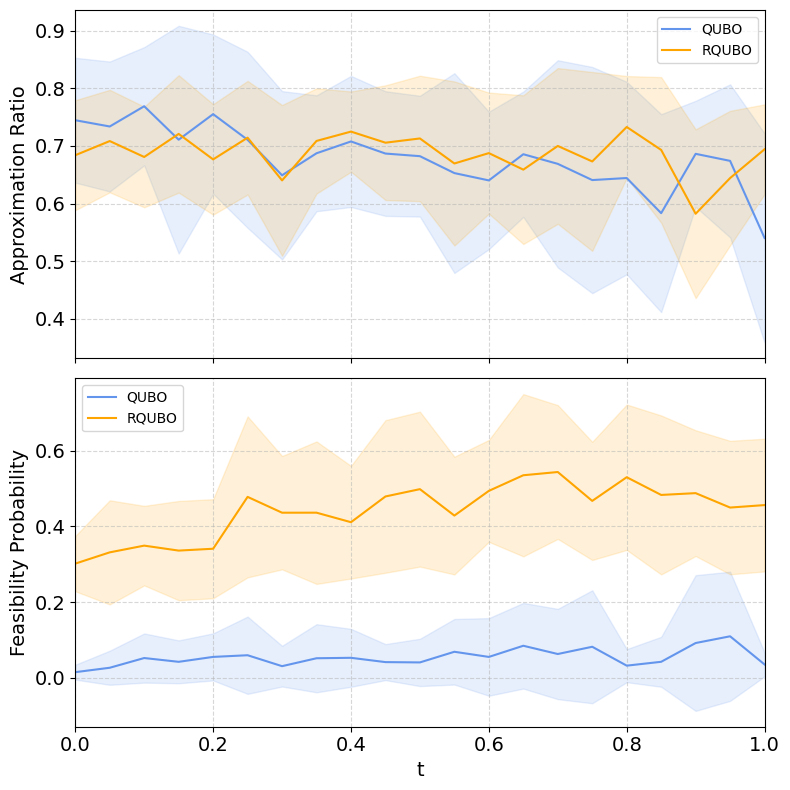

In [4]:
qubo_mean_over_graphs = np.mean(QUBO_EXP_VALS, axis=0)
qubo_std_over_graphs = np.std(QUBO_EXP_VALS, axis=0)
rqubo_mean_over_graphs = np.mean(RQUBO_EXP_VALS, axis=0)
rqubo_std_over_graphs = np.std(RQUBO_EXP_VALS, axis=0)

qubo_mean_feas_prob = np.mean(QUBO_FEASIBILITY, axis=0)
qubo_std_feas_prob = np.std(QUBO_FEASIBILITY, axis=0)
rqubo_mean_feas_prob = np.mean(RQUBO_FEASIBILITY, axis=0)
rqubo_std_feas_prob = np.std(RQUBO_FEASIBILITY, axis=0)

# Plotting

# Custom colors:
qubo_color = "cornflowerblue"
rqubo_color = "orange"

# Create a 2-row figure: top row for expected ratio, bottom row for feasibility probability.
# By specifying squeeze=False, axs is always a 2D array with shape (2, len(alpha_list))
fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

# -----------------------------
# Plot in the top row: Expected Approximation Ratio
# -----------------------------
ax_top = axs[0]
ax_top.plot(penalty_list, qubo_mean_over_graphs, label="QUBO", color=qubo_color, linestyle='-')
ax_top.fill_between(penalty_list,
                    np.array(qubo_mean_over_graphs) - np.array(qubo_std_over_graphs),
                    np.array(qubo_mean_over_graphs) + np.array(qubo_std_over_graphs),
                    color=qubo_color, alpha=0.15)

ax_top.plot(penalty_list, rqubo_mean_over_graphs, label="RQUBO", color=rqubo_color, linestyle='-')
ax_top.fill_between(penalty_list,
                    np.array(rqubo_mean_over_graphs) - np.array(rqubo_std_over_graphs),
                    np.array(rqubo_mean_over_graphs) + np.array(rqubo_std_over_graphs),
                    color=rqubo_color, alpha=0.15)

ax_top.grid(True, which='both', linestyle='--', alpha=0.5)
#ax_top.set_ylim(0, 1)
ax_top.set_ylabel('Approximation Ratio', fontsize=14)
ax_top.legend()
plt.grid

# -----------------------------
# Plot in the bottom row: Feasibility Probability
# -----------------------------
ax_bottom = axs[1]
ax_bottom.plot(penalty_list, qubo_mean_feas_prob, label="QUBO", color=qubo_color, linestyle='-')
ax_bottom.fill_between(penalty_list,
                    np.array(qubo_mean_feas_prob) - np.array(qubo_std_feas_prob),
                    np.array(qubo_mean_feas_prob) + np.array(qubo_std_feas_prob),
                    color=qubo_color, alpha=0.15)

ax_bottom.plot(penalty_list, rqubo_mean_feas_prob, label="RQUBO", color=rqubo_color, linestyle='-')
ax_bottom.fill_between(penalty_list,
                    np.array(rqubo_mean_feas_prob) - np.array(rqubo_std_feas_prob),
                    np.array(rqubo_mean_feas_prob) + np.array(rqubo_std_feas_prob),
                    color=rqubo_color, alpha=0.15)

ax_bottom.grid(True, which='both', linestyle='--', alpha=0.5)
#ax_bottom.set_ylim(0, .5)
ax_bottom.set_xlabel('t', fontsize=14)
ax_bottom.set_ylabel('Feasibility Probability', fontsize=14)
ax_bottom.legend()

for ax in axs:
    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=14)
    plt.xlim(0, 1)

plt.tight_layout()

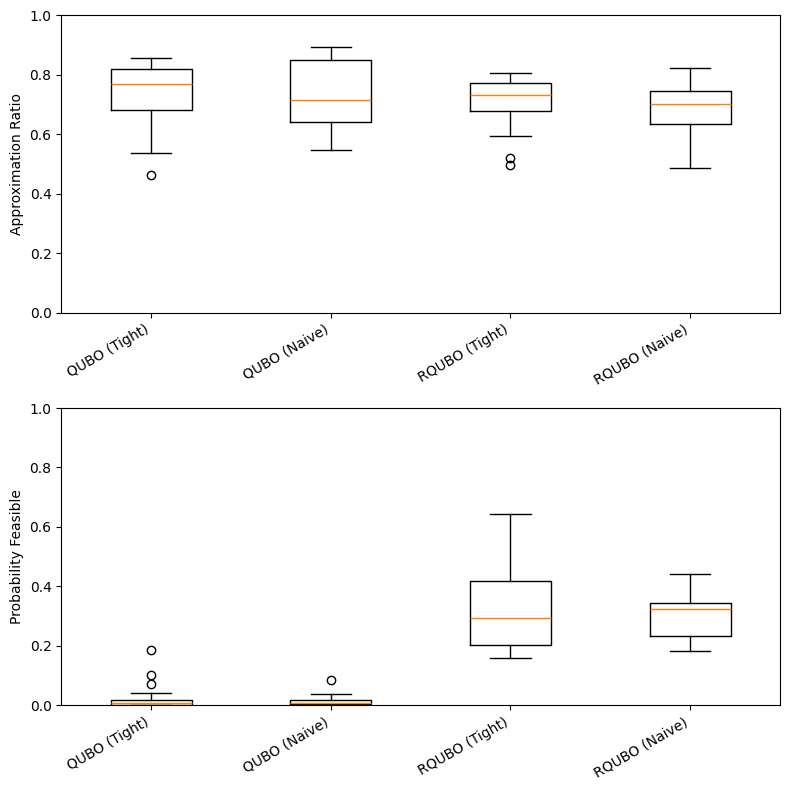

In [5]:
# Box Plot

model_labels = ["QUBO (Tight)", "QUBO (Naive)", "RQUBO (Tight)", "RQUBO (Naive)"]
model_means = {label: [] for label in model_labels}
model_feasibility_probs = {label: [] for label in model_labels}

model_means["QUBO (Tight)"] = QUBO_EXP_VALS[:, 1]
model_means["QUBO (Naive)"] = QUBO_EXP_VALS[:, 0]
model_means["RQUBO (Tight)"] = RQUBO_EXP_VALS[:, 1]
model_means["RQUBO (Naive)"] = RQUBO_EXP_VALS[:, 0]

model_feasibility_probs["QUBO (Tight)"] = QUBO_FEASIBILITY[:, 1]
model_feasibility_probs["QUBO (Naive)"] = QUBO_FEASIBILITY[:, 0]
model_feasibility_probs["RQUBO (Tight)"] = RQUBO_FEASIBILITY[:, 1]
model_feasibility_probs["RQUBO (Naive)"] = RQUBO_FEASIBILITY[:, 0]

fig, axs = plt.subplots(2, 1, figsize=(8, 8))

# First subplot: Approximation Ratio
data_for_boxplot = [model_means[label] for label in model_labels]
axs[0].boxplot(data_for_boxplot, tick_labels=model_labels)
axs[0].set_ylabel("Approximation Ratio")
axs[0].set_xticklabels(model_labels, rotation=30, ha='right')
axs[0].set_ylim(0, 1)

# Second subplot: Probability Feasible
data_for_boxplot = [model_feasibility_probs[label] for label in model_labels]
axs[1].boxplot(data_for_boxplot, tick_labels=model_labels)
axs[1].set_ylabel("Probability Feasible")
axs[1].set_xticklabels(model_labels, rotation=30, ha='right')
axs[1].set_ylim(0, 1)

plt.tight_layout()

## Filter out expected values of zero resulting from all shots being discarded due to infeasibility. This occurs especially with QUBO model which consistently has a low feasibility probability.

In [6]:
# For each column in data matrix, drop zero values and average the rest
def average_non_zero(data):
    return np.array([np.mean(col[col != 0]) for col in data.T])

def std_non_zero(data):
    return np.array([np.std(col[col != 0]) for col in data.T])

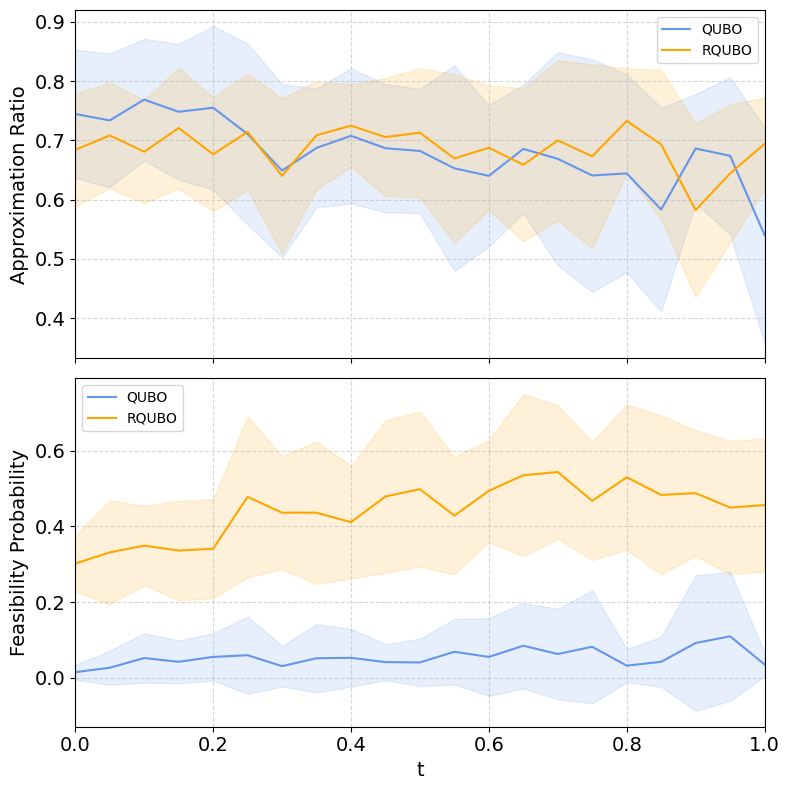

In [7]:
qubo_mean_over_graphs = average_non_zero(QUBO_EXP_VALS)
qubo_std_over_graphs = std_non_zero(QUBO_EXP_VALS)
rqubo_mean_over_graphs = average_non_zero(RQUBO_EXP_VALS)
rqubo_std_over_graphs = std_non_zero(RQUBO_EXP_VALS)

qubo_mean_feas_prob = np.mean(QUBO_FEASIBILITY, axis=0)
qubo_std_feas_prob = np.std(QUBO_FEASIBILITY, axis=0)
rqubo_mean_feas_prob = np.mean(RQUBO_FEASIBILITY, axis=0)
rqubo_std_feas_prob = np.std(RQUBO_FEASIBILITY, axis=0)

# Plotting

# Custom colors:
qubo_color = "cornflowerblue"
rqubo_color = "orange"

# Create a 2-row figure: top row for expected ratio, bottom row for feasibility probability.
# By specifying squeeze=False, axs is always a 2D array with shape (2, len(alpha_list))
fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

# -----------------------------
# Plot in the top row: Expected Approximation Ratio
# -----------------------------
ax_top = axs[0]
ax_top.plot(penalty_list, qubo_mean_over_graphs, label="QUBO", color=qubo_color, linestyle='-')
ax_top.fill_between(penalty_list,
                    np.array(qubo_mean_over_graphs) - np.array(qubo_std_over_graphs),
                    np.array(qubo_mean_over_graphs) + np.array(qubo_std_over_graphs),
                    color=qubo_color, alpha=0.15)

ax_top.plot(penalty_list, rqubo_mean_over_graphs, label="RQUBO", color=rqubo_color, linestyle='-')
ax_top.fill_between(penalty_list,
                    np.array(rqubo_mean_over_graphs) - np.array(rqubo_std_over_graphs),
                    np.array(rqubo_mean_over_graphs) + np.array(rqubo_std_over_graphs),
                    color=rqubo_color, alpha=0.15)

ax_top.grid(True, which='both', linestyle='--', alpha=0.5)
#ax_top.set_ylim(0, 1)
ax_top.set_ylabel('Approximation Ratio', fontsize=14)
ax_top.legend()
plt.grid

# -----------------------------
# Plot in the bottom row: Feasibility Probability
# -----------------------------
ax_bottom = axs[1]
ax_bottom.plot(penalty_list, qubo_mean_feas_prob, label="QUBO", color=qubo_color, linestyle='-')
ax_bottom.fill_between(penalty_list,
                    np.array(qubo_mean_feas_prob) - np.array(qubo_std_feas_prob),
                    np.array(qubo_mean_feas_prob) + np.array(qubo_std_feas_prob),
                    color=qubo_color, alpha=0.15)

ax_bottom.plot(penalty_list, rqubo_mean_feas_prob, label="RQUBO", color=rqubo_color, linestyle='-')
ax_bottom.fill_between(penalty_list,
                    np.array(rqubo_mean_feas_prob) - np.array(rqubo_std_feas_prob),
                    np.array(rqubo_mean_feas_prob) + np.array(rqubo_std_feas_prob),
                    color=rqubo_color, alpha=0.15)

ax_bottom.grid(True, which='both', linestyle='--', alpha=0.5)
#ax_bottom.set_ylim(0, .5)
ax_bottom.set_xlabel('t', fontsize=14)
ax_bottom.set_ylabel('Feasibility Probability', fontsize=14)
ax_bottom.legend()

for ax in axs:
    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=14)
    plt.xlim(0, 1)

plt.tight_layout()

fig.savefig(os.path.join("Data", "interpolated_penalties_final.png"), dpi=300)

In [8]:
print("feasibility probability ratio:", rqubo_mean_feas_prob / qubo_mean_feas_prob)
print("average ratio:", np.mean(rqubo_mean_feas_prob / qubo_mean_feas_prob))

feasibility probability ratio: [20.77444904 12.65559374  6.7267649   8.02327524  6.213173    8.06229978
 14.35279605  8.49897751  7.832      11.6537386  12.37154199  6.26097116
  9.00756609  6.34467026  8.6960032   5.72282742 16.69548103 11.5239628
  5.32822052  4.11237547 13.07187858]
average ratio: 9.710884113285548


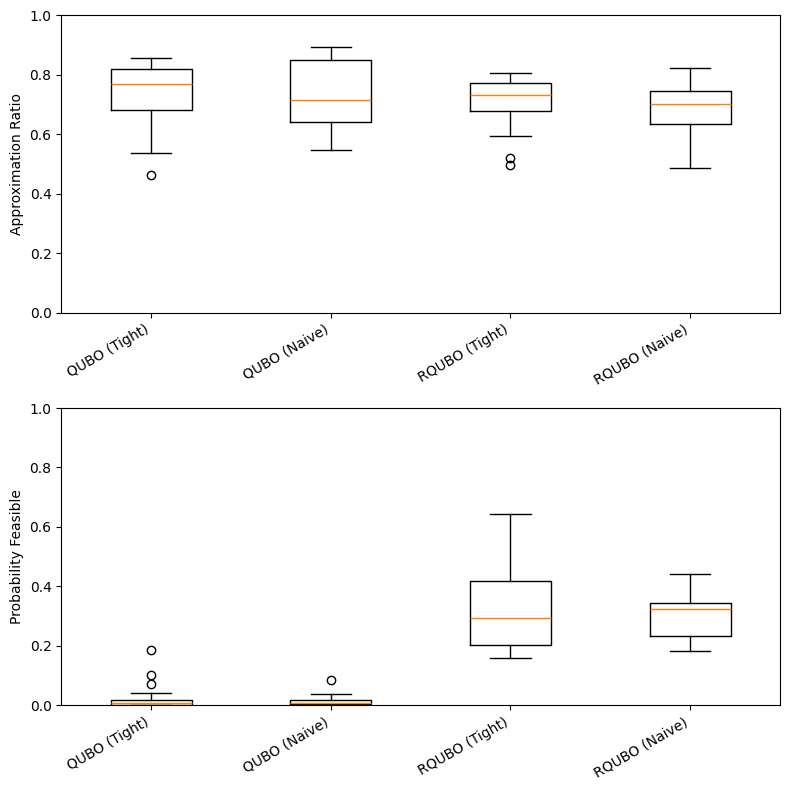

In [9]:
# Box Plot

model_labels = ["QUBO (Tight)", "QUBO (Naive)", "RQUBO (Tight)", "RQUBO (Naive)"]
model_means = {label: [] for label in model_labels}
model_feasibility_probs = {label: [] for label in model_labels}

# drop values that are 0
model_means["QUBO (Tight)"] = QUBO_EXP_VALS[:, 1][QUBO_EXP_VALS[:, 1] != 0]
model_means["QUBO (Naive)"] = QUBO_EXP_VALS[:, 0][QUBO_EXP_VALS[:, 0] != 0]
model_means["RQUBO (Tight)"] = RQUBO_EXP_VALS[:, 1][RQUBO_EXP_VALS[:, 1] != 0]
model_means["RQUBO (Naive)"] = RQUBO_EXP_VALS[:, 0][RQUBO_EXP_VALS[:, 0] != 0]

model_feasibility_probs["QUBO (Tight)"] = QUBO_FEASIBILITY[:, 1]
model_feasibility_probs["QUBO (Naive)"] = QUBO_FEASIBILITY[:, 0]
model_feasibility_probs["RQUBO (Tight)"] = RQUBO_FEASIBILITY[:, 1]
model_feasibility_probs["RQUBO (Naive)"] = RQUBO_FEASIBILITY[:, 0]

fig, axs = plt.subplots(2, 1, figsize=(8, 8))

# First subplot: Approximation Ratio
data_for_boxplot = [model_means[label] for label in model_labels]
axs[0].boxplot(data_for_boxplot, tick_labels=model_labels)
axs[0].set_ylabel("Approximation Ratio")
axs[0].set_xticklabels(model_labels, rotation=30, ha='right')
axs[0].set_ylim(0, 1)

# Second subplot: Probability Feasible
data_for_boxplot = [model_feasibility_probs[label] for label in model_labels]
axs[1].boxplot(data_for_boxplot, tick_labels=model_labels)
axs[1].set_ylabel("Probability Feasible")
axs[1].set_xticklabels(model_labels, rotation=30, ha='right')
axs[1].set_ylim(0, 1)

plt.tight_layout()

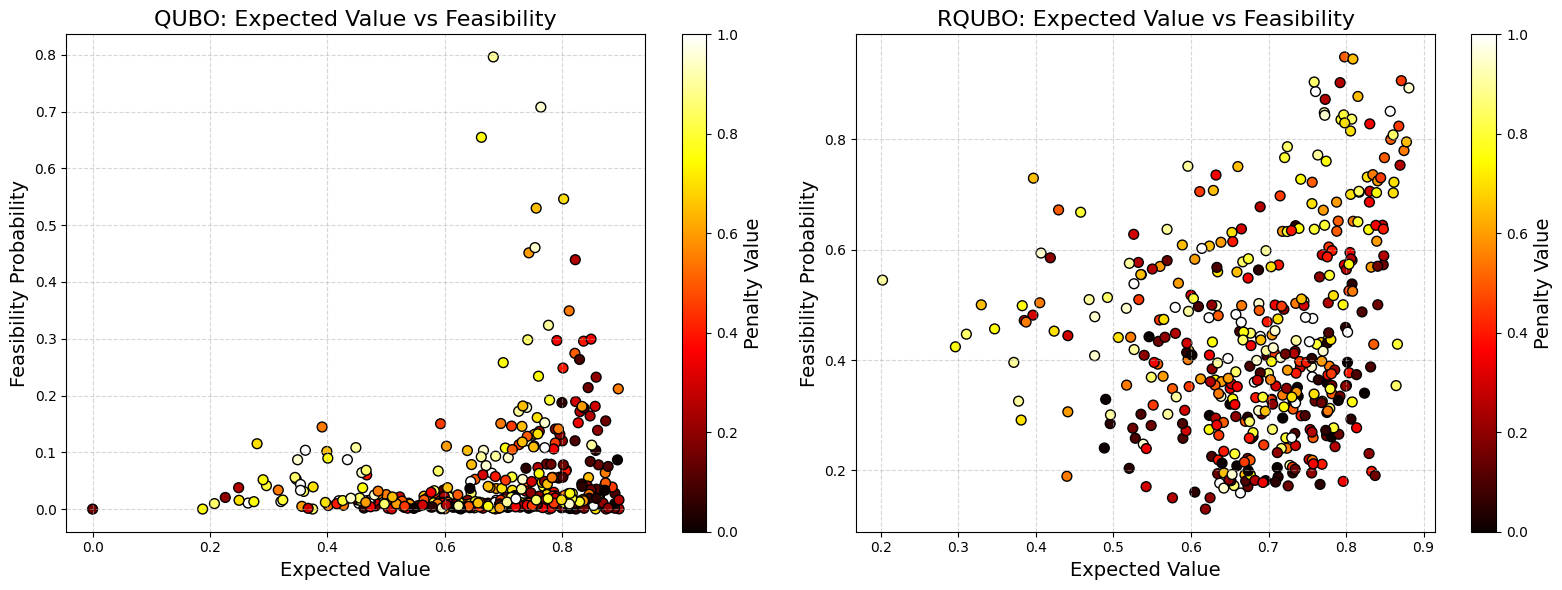

In [10]:
# Scatter of ALL data points

# Create color arrays for scatter plots.
# For each row (graph) we assign the penalty_list values.
colors = np.tile(penalty_list, (QUBO_EXP_VALS.shape[0], 1))  # shape (num_graphs, num_penalties)

# Flatten the matrices for plotting
qubo_exp_flat = QUBO_EXP_VALS.flatten()
qubo_feas_flat = QUBO_FEASIBILITY.flatten()
rqubo_exp_flat = RQUBO_EXP_VALS.flatten()
rqubo_feas_flat = RQUBO_FEASIBILITY.flatten()
colors_flat = colors.flatten()

# Create figure with two subplots.
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot for QUBO results
sc0 = axs[0].scatter(qubo_exp_flat, qubo_feas_flat, c=colors_flat, cmap='hot', s=50, edgecolor='k')
axs[0].set_xlabel('Expected Value', fontsize=14)
axs[0].set_ylabel('Feasibility Probability', fontsize=14)
axs[0].set_title('QUBO: Expected Value vs Feasibility', fontsize=16)
axs[0].grid(True, which='both', linestyle='--', alpha=0.5)
cbar0 = plt.colorbar(sc0, ax=axs[0])
cbar0.set_label('Penalty Value', fontsize=14)

# Scatter plot for RQUBO results
sc1 = axs[1].scatter(rqubo_exp_flat, rqubo_feas_flat, c=colors_flat, cmap='hot', s=50, edgecolor='k')
axs[1].set_xlabel('Expected Value', fontsize=14)
axs[1].set_ylabel('Feasibility Probability', fontsize=14)
axs[1].set_title('RQUBO: Expected Value vs Feasibility', fontsize=16)
axs[1].grid(True, which='both', linestyle='--', alpha=0.5)
cbar1 = plt.colorbar(sc1, ax=axs[1])
cbar1.set_label('Penalty Value', fontsize=14)

plt.tight_layout()
plt.show()

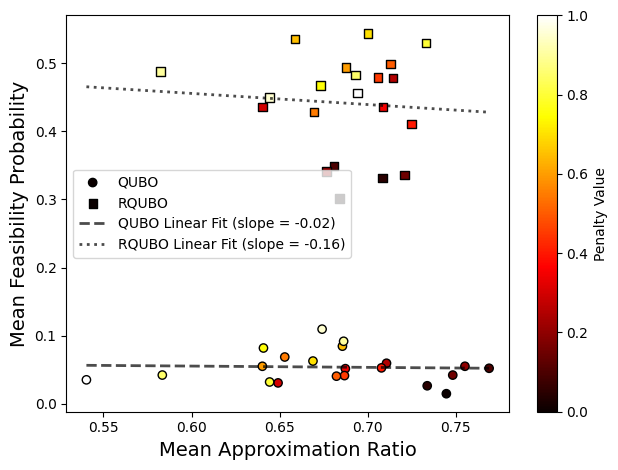

In [11]:
# Determine overall x range across both datasets
overall_min = np.min([np.min(qubo_mean_over_graphs), np.min(rqubo_mean_over_graphs)])
overall_max = np.max([np.max(qubo_mean_over_graphs), np.max(rqubo_mean_over_graphs)])
x_range = np.linspace(overall_min, overall_max, 100)

# Scatter of mean values over all graphs
plt.scatter(qubo_mean_over_graphs, qubo_mean_feas_prob, 
            c=penalty_list, cmap='hot', edgecolor='k', marker='o', label="QUBO")
plt.scatter(rqubo_mean_over_graphs, rqubo_mean_feas_prob, 
            c=penalty_list, cmap='hot', edgecolor='k', marker='s', label="RQUBO")
plt.colorbar(label='Penalty Value')

# Compute linear best fits for QUBO
coeffs_qubo = np.polyfit(qubo_mean_over_graphs, qubo_mean_feas_prob, 1)
slope_qubo = coeffs_qubo[0]
fit_qubo = np.poly1d(coeffs_qubo)
plt.plot(x_range, fit_qubo(x_range), color='k', linewidth=2, linestyle='dashed', alpha=0.7,
         label=f"QUBO Linear Fit (slope = {slope_qubo:.2f})")

# Compute linear best fits for RQUBO
coeffs_rqubo = np.polyfit(rqubo_mean_over_graphs, rqubo_mean_feas_prob, 1)
slope_rqubo = coeffs_rqubo[0]
fit_rqubo = np.poly1d(coeffs_rqubo)
plt.plot(x_range, fit_rqubo(x_range), color='k', linewidth=2, linestyle='dotted', alpha=0.7,
         label=f"RQUBO Linear Fit (slope = {slope_rqubo:.2f})")

plt.xlabel('Mean Approximation Ratio', fontsize=14)
plt.ylabel('Mean Feasibility Probability', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

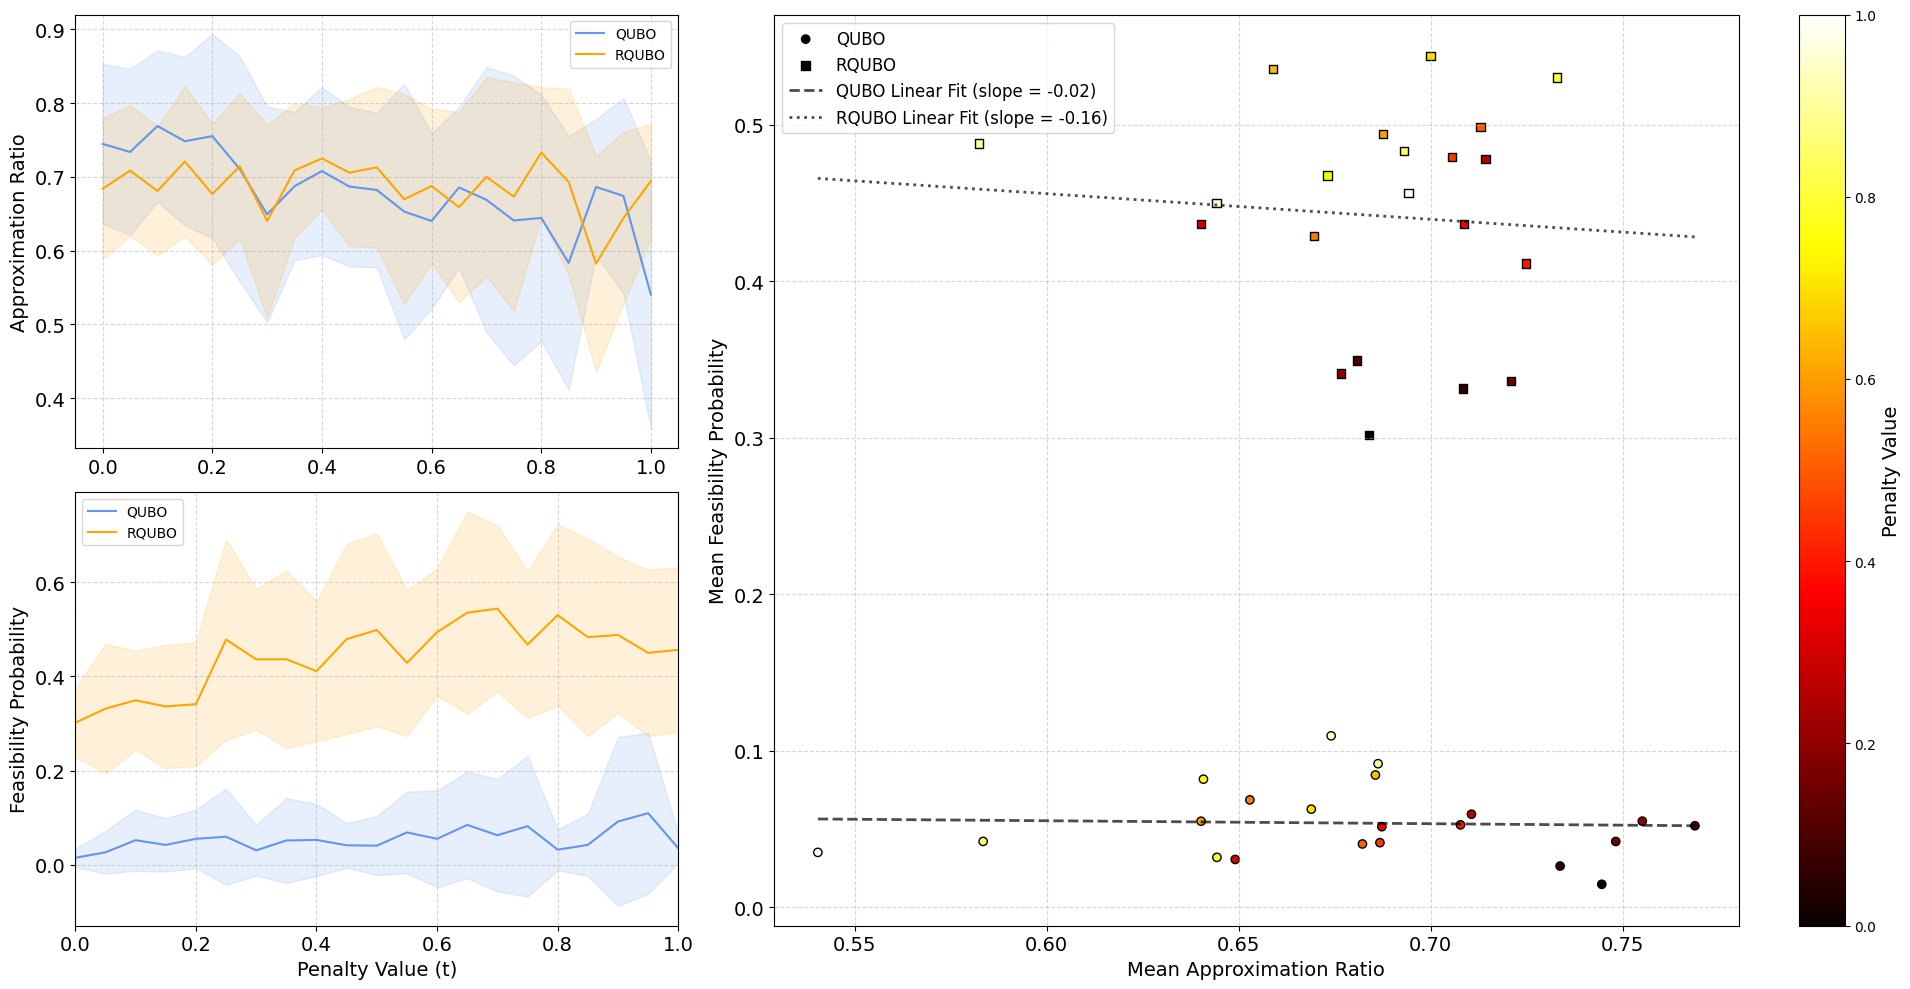

In [12]:
import matplotlib.gridspec as gridspec

# Custom colors:
qubo_color = "cornflowerblue"
rqubo_color = "orange"

# Assume the following variables are already defined:
# penalty_list : 1D array or list of penalty values
# qubo_mean_over_graphs, qubo_std_over_graphs : arrays for QUBO expected values and std (one per penalty)
# rqubo_mean_over_graphs, rqubo_std_over_graphs : arrays for RQUBO expected values and std
# qubo_mean_feas_prob, qubo_std_feas_prob : arrays for QUBO feasibility probabilities and std
# rqubo_mean_feas_prob, rqubo_std_feas_prob : arrays for RQUBO feasibility probabilities and std

# Create the figure using GridSpec:
fig = plt.figure(figsize=(20,10))
gs = gridspec.GridSpec(2, 2, width_ratios=[1, 2])  # 2 rows x 2 columns

# Left column subplots
ax_top = fig.add_subplot(gs[0, 0])
ax_bottom = fig.add_subplot(gs[1, 0])
# Right column subplot spanning both rows:
ax_scatter = fig.add_subplot(gs[:, 1])

# -----------------------------
# Left Column: Interpolation Plots
# -----------------------------
# Top row: Expected Approximation Ratio
ax_top.plot(penalty_list, qubo_mean_over_graphs, label="QUBO", color=qubo_color, linestyle='-')
ax_top.fill_between(penalty_list,
                    np.array(qubo_mean_over_graphs) - np.array(qubo_std_over_graphs),
                    np.array(qubo_mean_over_graphs) + np.array(qubo_std_over_graphs),
                    color=qubo_color, alpha=0.15)

ax_top.plot(penalty_list, rqubo_mean_over_graphs, label="RQUBO", color=rqubo_color, linestyle='-')
ax_top.fill_between(penalty_list,
                    np.array(rqubo_mean_over_graphs) - np.array(rqubo_std_over_graphs),
                    np.array(rqubo_mean_over_graphs) + np.array(rqubo_std_over_graphs),
                    color=rqubo_color, alpha=0.15)

ax_top.grid(True, which='both', linestyle='--', alpha=0.5)
ax_top.set_ylabel('Approximation Ratio', fontsize=14)
ax_top.legend()
ax_top.tick_params(axis='x', labelsize=14)
ax_top.tick_params(axis='y', labelsize=14)

# Bottom row: Feasibility Probability
ax_bottom.plot(penalty_list, qubo_mean_feas_prob, label="QUBO", color=qubo_color, linestyle='-')
ax_bottom.fill_between(penalty_list,
                    np.array(qubo_mean_feas_prob) - np.array(qubo_std_feas_prob),
                    np.array(qubo_mean_feas_prob) + np.array(qubo_std_feas_prob),
                    color=qubo_color, alpha=0.15)

ax_bottom.plot(penalty_list, rqubo_mean_feas_prob, label="RQUBO", color=rqubo_color, linestyle='-')
ax_bottom.fill_between(penalty_list,
                    np.array(rqubo_mean_feas_prob) - np.array(rqubo_std_feas_prob),
                    np.array(rqubo_mean_feas_prob) + np.array(rqubo_std_feas_prob),
                    color=rqubo_color, alpha=0.15)

ax_bottom.grid(True, which='both', linestyle='--', alpha=0.5)
ax_bottom.set_xlabel('Penalty Value (t)', fontsize=14)
ax_bottom.set_ylabel('Feasibility Probability', fontsize=14)
ax_bottom.legend()
ax_bottom.tick_params(axis='x', labelsize=14)
ax_bottom.tick_params(axis='y', labelsize=14)
ax_bottom.set_xlim(0, 1)

# -----------------------------
# Right Column: Scatter Plot with Linear Best Fits
# -----------------------------
# For scatter, assume each mean value array is 1D with length = len(penalty_list).
# We'll use the same penalty_list as the color information for all points.
# Create scatter plot for QUBO and RQUBO data:
sc_qubo = ax_scatter.scatter(qubo_mean_over_graphs, qubo_mean_feas_prob, 
                             c=penalty_list, cmap='hot', edgecolor='k', marker='o', label="QUBO")
sc_rqubo = ax_scatter.scatter(rqubo_mean_over_graphs, rqubo_mean_feas_prob, 
                              c=penalty_list, cmap='hot', edgecolor='k', marker='s', label="RQUBO")
cbar = plt.colorbar(sc_rqubo, ax=ax_scatter)
cbar.set_label('Penalty Value', fontsize=14)

# Determine overall x range across both datasets using a list wrapper:
overall_min = np.min([np.min(qubo_mean_over_graphs), np.min(rqubo_mean_over_graphs)])
overall_max = np.max([np.max(qubo_mean_over_graphs), np.max(rqubo_mean_over_graphs)])
x_range = np.linspace(overall_min, overall_max, 100)

# Compute linear best fits for QUBO
coeffs_qubo = np.polyfit(qubo_mean_over_graphs, qubo_mean_feas_prob, 1)
slope_qubo = coeffs_qubo[0]
fit_qubo = np.poly1d(coeffs_qubo)
ax_scatter.plot(x_range, fit_qubo(x_range), color='k', linewidth=2, linestyle='dashed', alpha=0.7,
         label=f"QUBO Linear Fit (slope = {slope_qubo:.2f})")

# Compute linear best fits for RQUBO
coeffs_rqubo = np.polyfit(rqubo_mean_over_graphs, rqubo_mean_feas_prob, 1)
slope_rqubo = coeffs_rqubo[0]
fit_rqubo = np.poly1d(coeffs_rqubo)
ax_scatter.plot(x_range, fit_rqubo(x_range), color='k', linewidth=2, linestyle='dotted', alpha=0.7,
         label=f"RQUBO Linear Fit (slope = {slope_rqubo:.2f})")

ax_scatter.set_xlabel('Mean Approximation Ratio', fontsize=14)
ax_scatter.set_ylabel('Mean Feasibility Probability', fontsize=14)
ax_scatter.legend(fontsize=12)
ax_scatter.grid(True, which='both', linestyle='--', alpha=0.5)
ax_scatter.tick_params(axis='x', labelsize=14)
ax_scatter.tick_params(axis='y', labelsize=14)

plt.tight_layout()
plt.show()

/var/folders/zv/92_qyn4s5v7f__ysxhlg_ykw0000gn/T/ipykernel_9392/3239431526.py:117: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


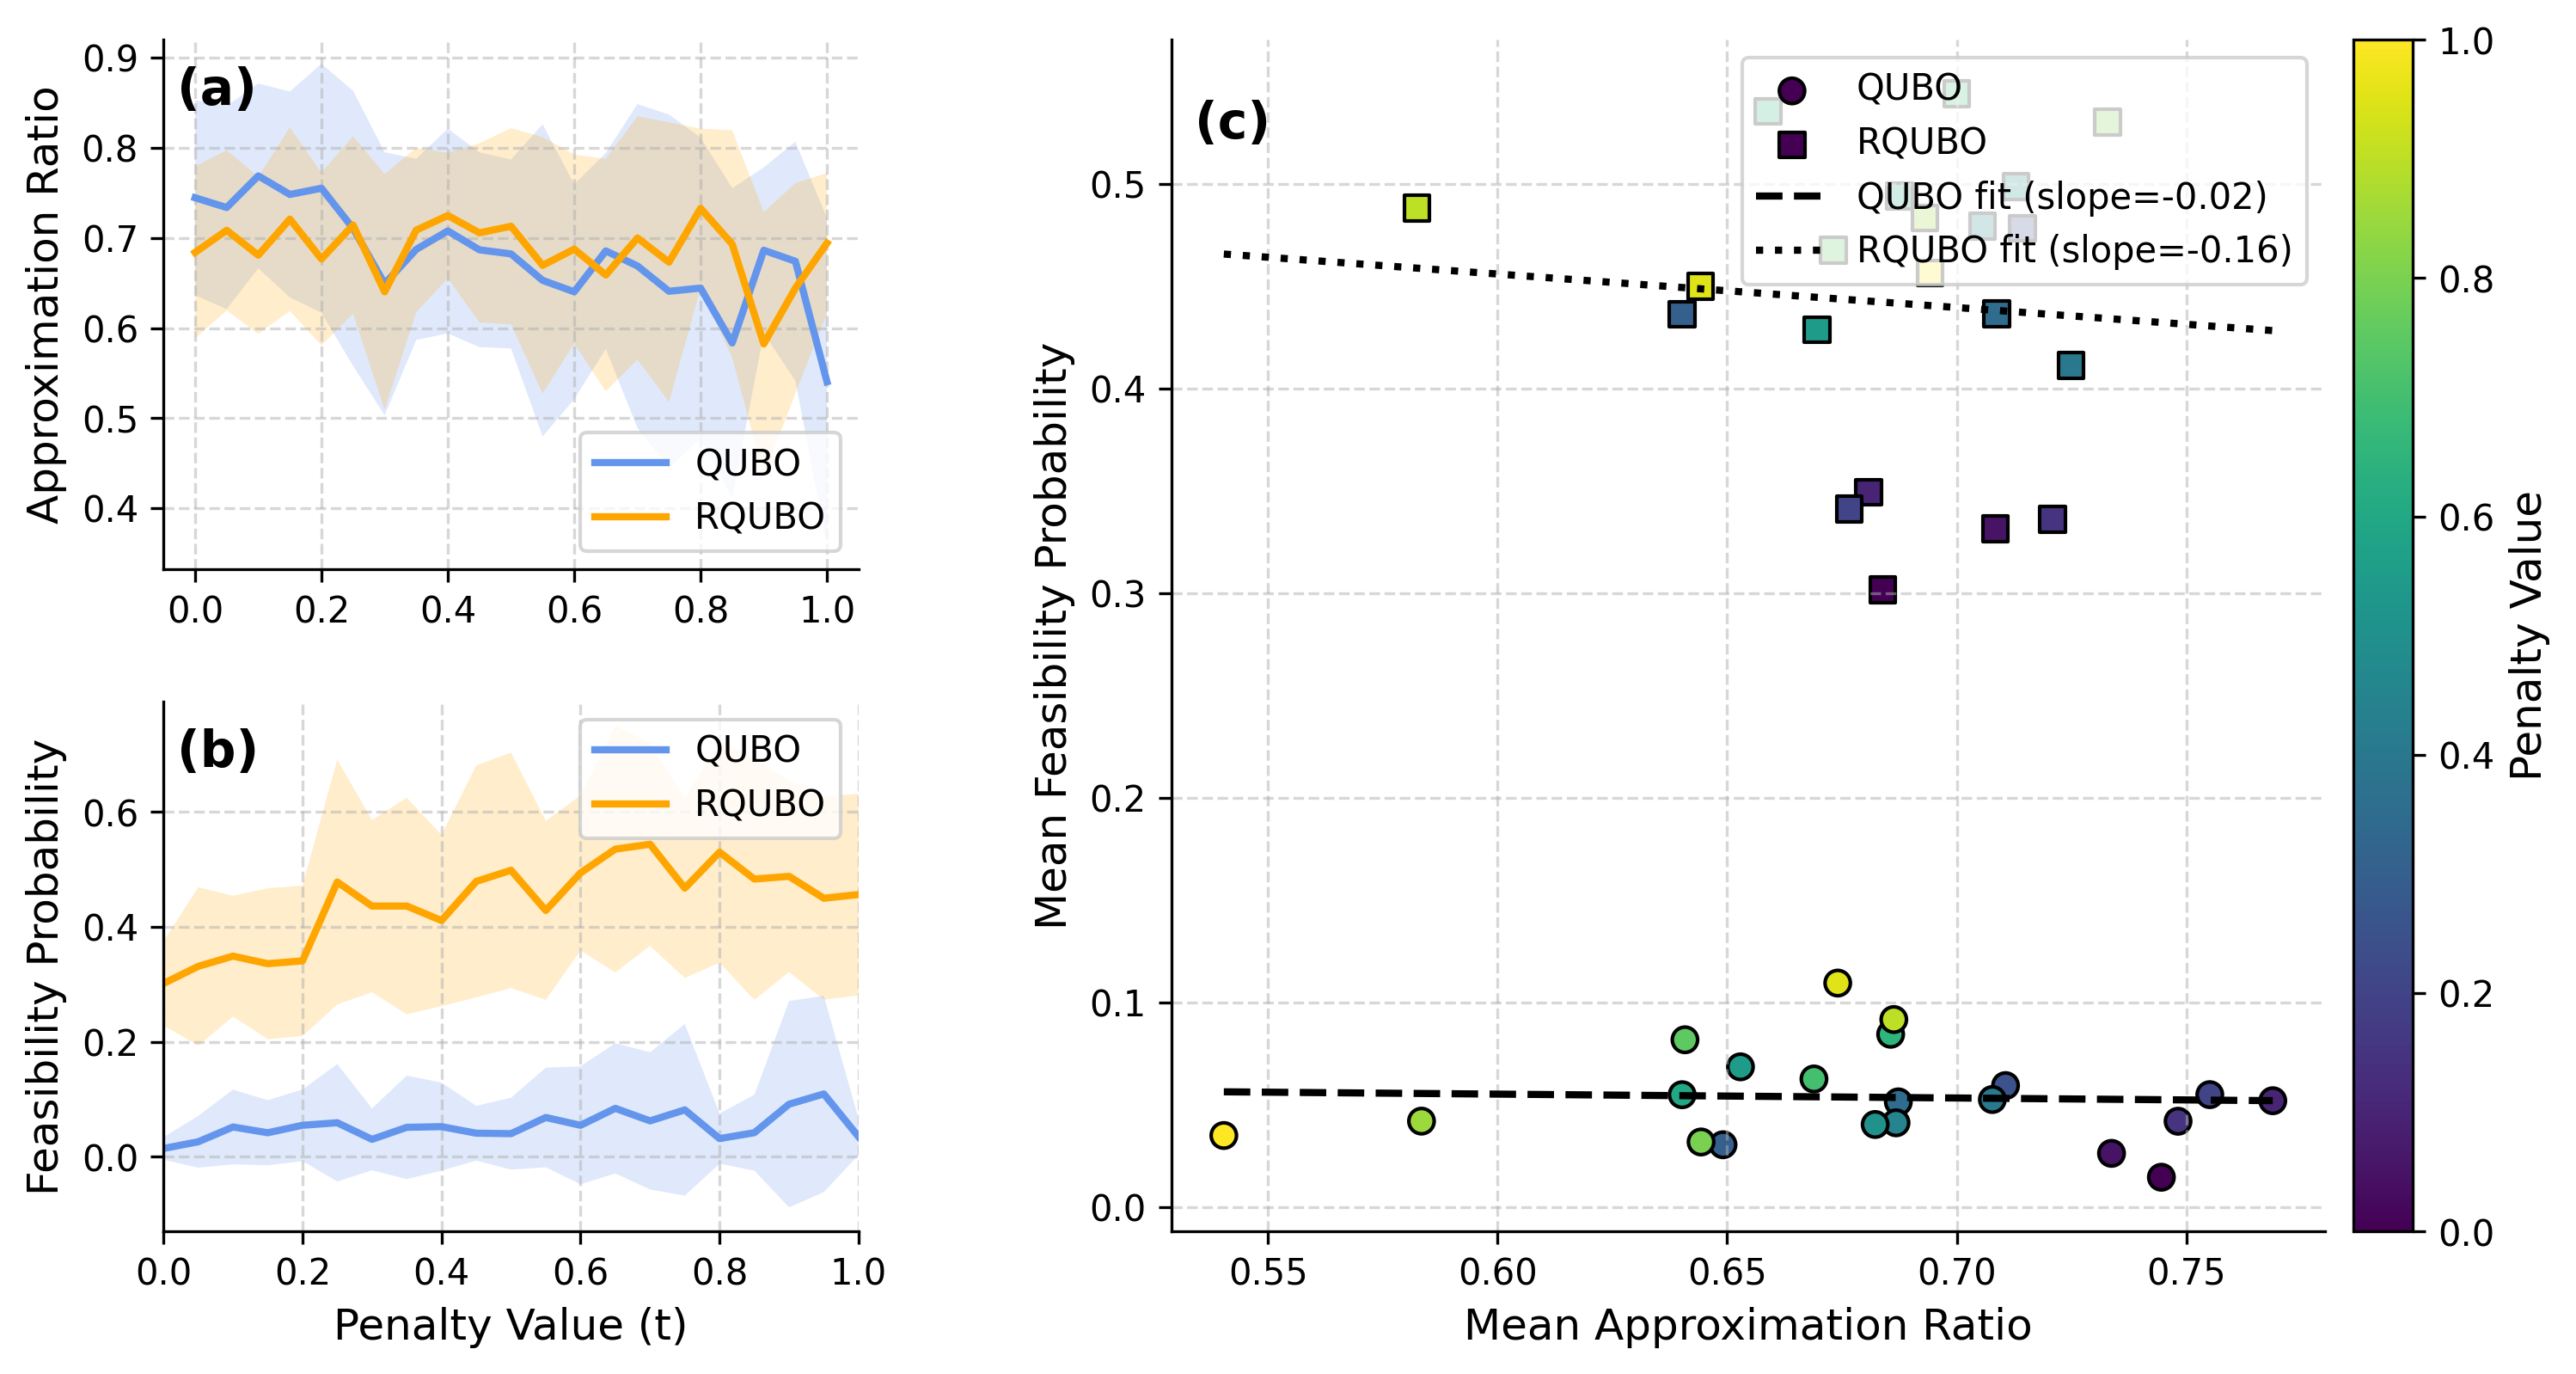

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# --- assume your data arrays are already defined above ---
# penalty_list, qubo_mean_over_graphs, qubo_std_over_graphs, etc.

# Choose a perceptually uniform colormap & normalization
cmap = plt.cm.viridis
norm = Normalize(vmin=min(penalty_list), vmax=max(penalty_list))

# Create high‑dpi figure with 2×2 grid (right span = 2 rows)
fig = plt.figure(figsize=(12, 6), dpi=300)
gs  = GridSpec(2, 2, width_ratios=[1, 2], wspace=0.3, hspace=0.25)
ax1 = fig.add_subplot(gs[0, 0])  # (a) Approx ratio vs. penalty
ax2 = fig.add_subplot(gs[1, 0])  # (b) Feasibility vs. penalty
ax3 = fig.add_subplot(gs[:, 1])  # (c) Scatter with fits

# --- Panel (a): Approximation Ratio ---
ax1.plot(penalty_list, qubo_mean_over_graphs,
         color='cornflowerblue', linewidth=2, label='QUBO')
ax1.fill_between(penalty_list,
                 np.array(qubo_mean_over_graphs) - qubo_std_over_graphs,
                 np.array(qubo_mean_over_graphs) + qubo_std_over_graphs,
                 facecolor='cornflowerblue', alpha=0.2)

ax1.plot(penalty_list, rqubo_mean_over_graphs,
         color='orange', linewidth=2, label='RQUBO')
ax1.fill_between(penalty_list,
                 np.array(rqubo_mean_over_graphs) - rqubo_std_over_graphs,
                 np.array(rqubo_mean_over_graphs) + rqubo_std_over_graphs,
                 facecolor='orange', alpha=0.2)

ax1.set_ylabel("Approximation Ratio", fontsize=12)
ax1.grid(linestyle='--', alpha=0.5)
ax1.legend(fontsize=10, loc='lower right')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.text(0.02, 0.95, "(a)",
         transform=ax1.transAxes,
         fontsize=14, fontweight='bold', va='top')

# --- Panel (b): Feasibility Probability ---
ax2.plot(penalty_list, qubo_mean_feas_prob,
         color='cornflowerblue', linewidth=2, label='QUBO')
ax2.fill_between(penalty_list,
                 np.array(qubo_mean_feas_prob) - qubo_std_feas_prob,
                 np.array(qubo_mean_feas_prob) + qubo_std_feas_prob,
                 facecolor='cornflowerblue', alpha=0.2)

ax2.plot(penalty_list, rqubo_mean_feas_prob,
         color='orange', linewidth=2, label='RQUBO')
ax2.fill_between(penalty_list,
                 np.array(rqubo_mean_feas_prob) - rqubo_std_feas_prob,
                 np.array(rqubo_mean_feas_prob) + rqubo_std_feas_prob,
                 facecolor='orange', alpha=0.2)

ax2.set_xlabel("Penalty Value (t)",      fontsize=12)
ax2.set_ylabel("Feasibility Probability", fontsize=12)
ax2.set_xlim(0, 1)
ax2.grid(linestyle='--', alpha=0.5)
ax2.legend(fontsize=10, loc='upper right')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.text(0.02, 0.95, "(b)",
         transform=ax2.transAxes,
         fontsize=14, fontweight='bold', va='top')

# --- Panel (c): Scatter + Linear Fits ---
# Plot QUBO points
ax3.scatter(qubo_mean_over_graphs, qubo_mean_feas_prob,
            c=penalty_list, cmap=cmap, norm=norm,
            s=50, edgecolor='k', marker='o', label='QUBO')

# Plot RQUBO points
ax3.scatter(rqubo_mean_over_graphs, rqubo_mean_feas_prob,
            c=penalty_list, cmap=cmap, norm=norm,
            s=50, edgecolor='k', marker='s', label='RQUBO')

# Colorbar (shared mappable)
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax3, pad=0.02)
cbar.set_label("Penalty Value", fontsize=12)

# Linear fits
x_min = min(min(qubo_mean_over_graphs), min(rqubo_mean_over_graphs))
x_max = max(max(qubo_mean_over_graphs), max(rqubo_mean_over_graphs))
x_range = np.linspace(x_min, x_max, 100)

# QUBO fit
coef_q = np.polyfit(qubo_mean_over_graphs, qubo_mean_feas_prob, 1)
fit_q   = np.poly1d(coef_q)
ax3.plot(x_range, fit_q(x_range),
         linestyle='--', color='k', linewidth=2,
         label=f"QUBO fit (slope={coef_q[0]:.2f})")

# RQUBO fit
coef_r = np.polyfit(rqubo_mean_over_graphs, rqubo_mean_feas_prob, 1)
fit_r   = np.poly1d(coef_r)
ax3.plot(x_range, fit_r(x_range),
         linestyle=':',  color='k', linewidth=2,
         label=f"RQUBO fit (slope={coef_r[0]:.2f})")

ax3.set_xlabel("Mean Approximation Ratio",        fontsize=12)
ax3.set_ylabel("Mean Feasibility Probability",    fontsize=12)
ax3.grid(linestyle='--', alpha=0.5)
ax3.legend(fontsize=10, loc='upper right')
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.text(0.02, 0.95, "(c)",
         transform=ax3.transAxes,
         fontsize=14, fontweight='bold', va='top')

plt.tight_layout()
plt.show()